Exploratory Data Analysis (EDA) is the process of examining, visualising, and summarising the key elements of a dataset before proceeding with formal modelling or hypothesis testing.  The goal is to gain a thorough, intuitive knowledge of the data by recognising patterns, trends, anomalies, and correlations among variables.  EDA often includes visual approaches like histograms, box plots, scatter plots, and heatmaps, as well as descriptive statistics (mean, median, variance, etc.) to assist analysts "get a feel" for the data in an open-minded and flexible manner.

The Key aspects of EDA include:

* Detecting data quality issues (missing values, outliers, errors).

* Understanding distributions, relationships, and structure in the data.

* Testing informal hypotheses and uncovering unexpected patterns or trends.

* Informing next steps for deeper statistical modeling or data cleaning.

### Summary Statistics
Summary statistics are numerical values that summarise and provide concise information about a dataset, allowing you to better understand and interpret the data's characteristics. They describe the data's central tendency, variability, and distribution shape.

The main components of descriptive statistics include:

* **Measures of Location (Central Tendency)**: These describe the center of the data distribution, such as the mean (average), median (middle value), and mode (most frequent value).

* **Measures of Variability (Spread)**: These describe how spread out the data points are, including variance, standard deviation, range, skewness (asymmetry), and kurtosis (tailedness).

* **Measures of Shape**: Describe the distribution shape, such as skewness (asymmetry) and kurtosis (tailedness).

Let's explore the tips dataset as an example. The dataset contains tips customers gave to waiters at a restaurant.

In [40]:
import pandas as pd

In [41]:
tips = pd.read_csv("../data/tips.csv")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [42]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


#### Measures of Location (Central Tendency) and Variablity

In [43]:
tips_summary = tips.describe(include="all")
tips_summary

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


##### Mean

The mean is the most popular measure of central tendency. It is the arithmetric average of all the values in a dataset. It is calculated by summing all values and dividing by the number of values.

In [44]:
tips_summary.loc["mean"]

total_bill    19.785943
tip            2.998279
sex                 NaN
smoker              NaN
day                 NaN
time                NaN
size           2.569672
Name: mean, dtype: object

##### Median

The middle value in a dataset when the values are arranged in ascending or descending order. If there's an even number of values, it's the average of the two middle values. It best used for describing skewed data or data with outliers, as it is not affected by extreme values.

In [45]:
tips_summary.loc["50%"]

total_bill    17.795
tip              2.9
sex              NaN
smoker           NaN
day              NaN
time             NaN
size             2.0
Name: 50%, dtype: object

##### Mode

The value that appears most frequently in a dataset. A dataset can have one mode (unimodal), multiple modes (multimodal), or no mode. It is useful for categorical data or discrete numerical data to identify the most common category or value.

In [46]:
tips_summary.loc["top"]

total_bill       NaN
tip              NaN
sex             Male
smoker            No
day              Sat
time          Dinner
size             NaN
Name: top, dtype: object

#### Measures of Dispersion (Variability)

##### Variance

The average of the squared differences from the mean. It measures how far each number in the dataset is from the mean. it useful for understanding the spread, but the units are squared, making interpretation difficult.

In [47]:
tips.select_dtypes("number").var()

total_bill    79.252939
tip            1.914455
size           0.904591
dtype: float64

#### Standard Deviation

The square root of the variance. It's the most commonly used measure of spread and is in the same units as the original data, making it easier to interpret.

In [48]:
tips_summary.loc["std"]

total_bill    8.902412
tip           1.383638
sex                NaN
smoker             NaN
day                NaN
time               NaN
size            0.9511
Name: std, dtype: object

##### Range

The difference between the maximum and minimum values in a dataset. It is simple and quick, but highly sensitive to outliers.

In [49]:
tips_summary.loc[["min", "max"]]

,total_bill,tip,sex,smoker,day,time,size
min,3.07,1.0,NaN,NaN,NaN,NaN,1.0
max,50.81,10.0,NaN,NaN,NaN,NaN,6.0


In [50]:
tips_summary.loc["max"] - tips_summary.loc["min"]

total_bill    47.74
tip             9.0
sex             NaN
smoker          NaN
day             NaN
time            NaN
size            5.0
dtype: object

##### Interquartile Range (IQR)

The range between the first quartile (Q1, 25th percentile) and the third quartile (Q3, 75th percentile). It represents the middle 50% of the data.

$$ IQR=Q3−Q1$$

It is robust to outliers and preferred for skewed distributions.

In [51]:
Q1 = tips.select_dtypes("number").quantile(0.25)
Q3 = tips.select_dtypes("number").quantile(0.75)
iqr = Q3 - Q1
iqr

total_bill    10.7800
tip            1.5625
size           1.0000
dtype: float64

#### Measures of Shape

##### Skewness

Skewness is a statistical measure that describes the asymmetry or lack of symmetry in the distribution of data values. It indicates whether the data distribution leans more to one side of the mean, rather than being perfectly balanced.

* When the skewness is zero, the distribution is symmetric, meaning the left and right sides are mirror images. This is typical of a normal distribution.

* Positive skewness (right-skewed): The distribution's tail is longer or fatter on the right side. In this case, the mean is usually greater than the median. This indicates there are relatively more extreme values on the higher end.

* Negative skewness (left-skewed): The distribution's tail is longer or fatter on the left side. Here, the mean is typically less than the median, showing more extreme values on the lower end.

Skewness helps to understand the shape and characteristics of data, especially in determining if the data deviates from a normal (symmetrical) distribution, which is an assumption in many statistical methods.

In [52]:
tips.select_dtypes("number").skew()

total_bill    1.133213
tip           1.465451
size          1.447882
dtype: float64

##### Kurtosis

Kurtosis is a statistical metric that describes the "tailedness" of a probability distribution, or the frequency with which extreme values (outliers) occur in the tails of the distribution when compared to a normal distribution.  Unlike skewness, which measures asymmetry, kurtosis is concerned with the extremity and frequency of outliers in the tails rather than the peak shape.

The kurtosis value helps categorise distributions into three types:

* **Mesokurtic**: Medium-tailed distributions, similar to the normal distribution, with kurtosis around 3 (excess kurtosis of 0).

* **Leptokurtic**: Distributions with fat tails and a higher chance of outliers, kurtosis greater than 3 (positive excess kurtosis).

* **Platykurtic**: Distributions with thin tails and fewer outliers, kurtosis less than 3 (negative excess kurtosis).

Excess kurtosis is often used to compare kurtosis relative to the normal distribution, calculated as $excess \ kurtosis = kurtosis − 3$.

In [53]:
tips.select_dtypes("number").kurt()

total_bill    1.218484
tip           3.648376
size          1.731700
dtype: float64

### Exercise 1

Load the penguins dataset from the data folder and use it to answer the following questions:

1. What is the average mass of a penguin?
2. How many species of penguins are in the dataset?
3. Which specie is most common in the dataset?
4. How many samples of the most common specie are in the dataset?
5. What is the standard deviaton the body_mass of penguins?
6. Is the body mass data right skewed, left skewed, or symmetric?

### Data Distribution and Visualisation

A distribution refers to the way in which the values of a variable or set of variables are spread or arranged across different possible values in a dataset. An additional tool that helps us understand the distribution of our data better is data visualisation, a visual representation of data in form of charts, graphs, and maps. Data visualisation allows us to instantly identify patterns, trends, and insights in our data.

Here are the things visualisation of our data's distribution reveal:

* **Frequency of values**: Shows how often each value or range of values occurs in the dataset.

* **Shape**: Helps identify if the data is symmetric, skewed, has one or more peaks (modes), or long tails.

* **Center and spread**: Allows you to determine where most values concentrate (center), and how much they vary (spread).

* **Outliers and anomalies**: Makes it easier to spot unusual or extreme values.

* **Underlying assumptions**: Confirms if the data meets important requirements for further analysis (like normality for many statistical tests).

When it comes to data visualisation in Python, two powerful libraries stand out: **Matplotlib** and **Seaborn**. Matplotlib is the foundational building block for most data visualisation libries in Python. It's a comprehensive library that gives you fine-grained control over every aspect of your plots. Seaborn on the otherhand builds on Matplotlib by providing a higher-level interface for creating informative and attractive graphics.

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

### Exploring the distribution of numeric variables

#### Histograms
Histograms are used to visualize the distribution of a single numerical variable. They divide the data into bins and show the frequency (count) of data points falling into each bin.

In [55]:
tips.select_dtypes("number").columns

Index(['total_bill', 'tip', 'size'], dtype='object')

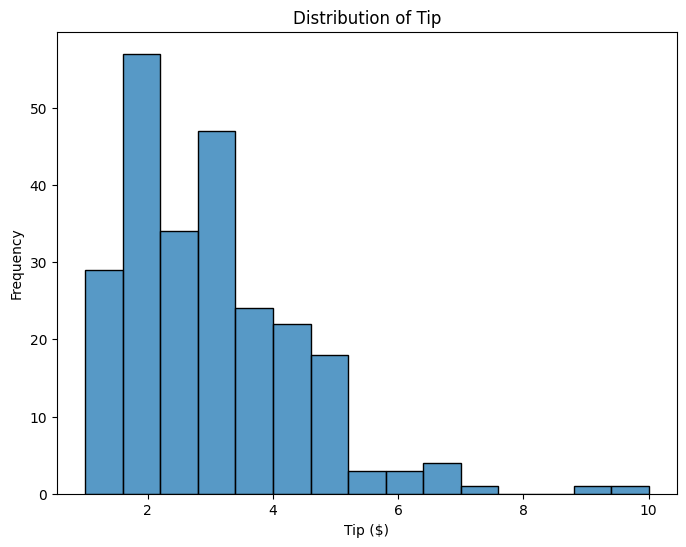

In [56]:
plt.figure(figsize=(8, 6))  # Controls the size of the plot
sns.histplot(tips["tip"], bins=15)  # Plots a history of total bills
plt.title("Distribution of Tip")  # Add title to the plot
plt.xlabel("Tip ($)")  # Add label for x axis
plt.ylabel("Frequency")  # Add label for y axis
plt.show()

Usually, we want to compare our data distribution to a normal distribution. A normal distribution is a probability distribution that looks like a bell shape curve with it's value symmetric around the mean.

<Axes: ylabel='Count'>

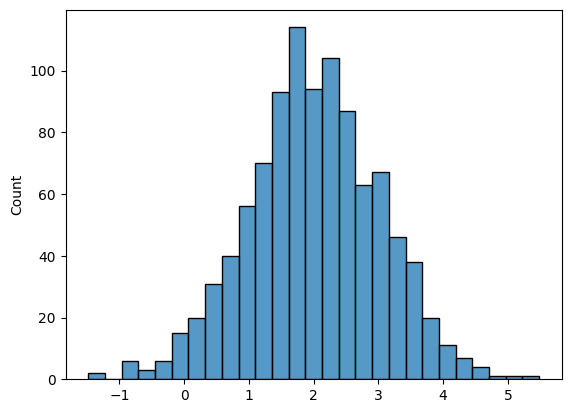

In [57]:
import numpy as np

y = np.random.normal(2, 1, size=1000)

sns.histplot(y)

#### Box plot
Box plots (or box-and-whisker plots) provide a summary of the distribution of a numerical variable, showing the median, quartiles, and potential outliers. They are particularly useful for comparing distributions across different categories

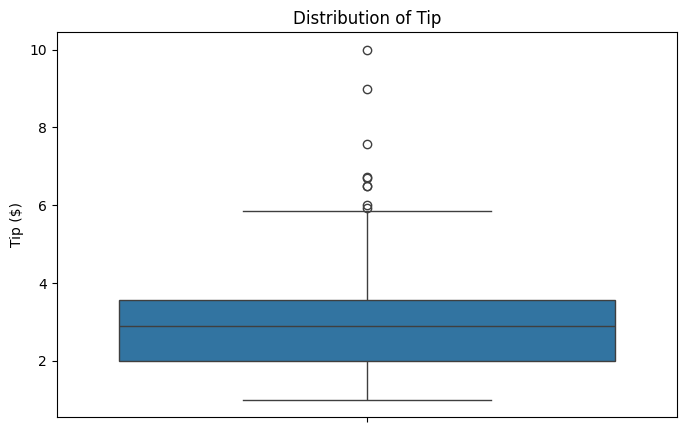

In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(tips["tip"])
plt.title("Distribution of Tip")
plt.ylabel("Tip ($)")
plt.show()

### Exploring the distribution of categorical variables

When exploring categorical data, we often check for the unique values and their frequencies.

#### Day Column/Feature

In [59]:
# Identify categories or unique values

tips["day"].unique()

array(['Sun', 'Sat', 'Thur', 'Fri'], dtype=object)

In [60]:
tips["day"].nunique()

4

In [61]:
# Frequency of categories

tips["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

#### Visualising frequency with bar Chart
Bar charts are used to compare categorical data, where the height of each bar represents the frequency or proportion of a particular category.

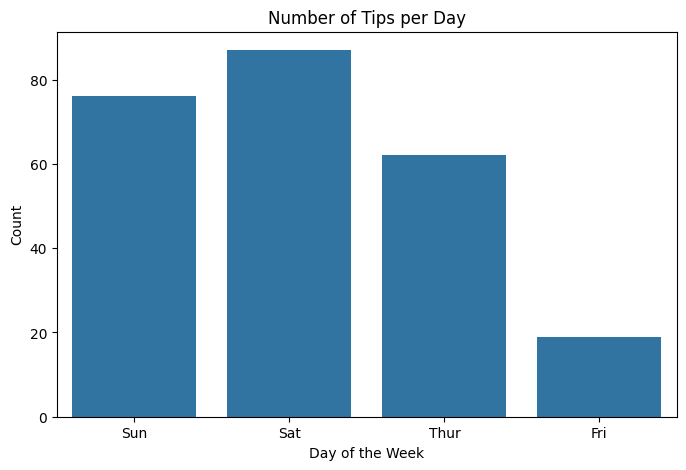

In [62]:
plt.figure(figsize=(8, 5))
sns.countplot(x="day", data=tips)
plt.title("Number of Tips per Day")
plt.xlabel("Day of the Week")
plt.ylabel("Count")
plt.show()

In [63]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

### Exercise 2

1. Visualise the distribution of the `total_bill` column with proper title and labels.
2. What is the shape of the distribution of `total_bill`?
3. Show the unqiue values in the `smoker` column?
4. Visualise the `smoker` column with a bar chart and proper labelling.

### Exploring Relationships

Another crucial step in EDA is exploring relationship between our target (prediction) variable and the feature (predictors) in our data.

#### Numerical vs Numerical

##### Correlation

When exploring relationship between numerical variables, we check for correlation and visualise the date with a scatter plot.

Correlation measures the strength and direction of a linear relationship between two numerical variables using a value called correlation coefficient. The value of the correlation coefficient ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear correlation. Correlation does not imply causation; it only indicates that two variables move together, not that one causes the other.

The correlation coefficient of tip and total bill approximately 0.68. This implies that there is a strong positive correlation between tip and total bill.

##### Visualising the correlation coefficients with a heatmap

A heatmap is a two-dimensional data visualisation approach that uses colours to indicate the magnitude of values in a dataset.  Different colours or shades represent different values, enabling for easy visual recognition of patterns, trends, or concentrations.  For example, darker or warmer colours (like red) frequently symbolise higher values, whereas lighter or cooler colours (like blue) represent lower values.

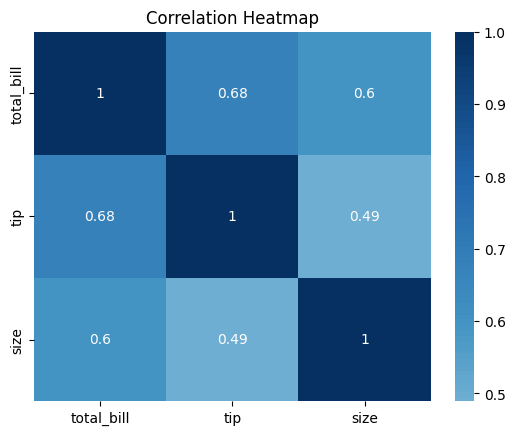

In [66]:
sns.heatmap(corr_coefs, cmap="RdBu", center=0.0, annot=True)
plt.title("Correlation Heatmap");

##### Visualising with a scatter plot
Scatter plots are used to visualise the relationship between two numerical variables. Each point on the plot represents a single data point.

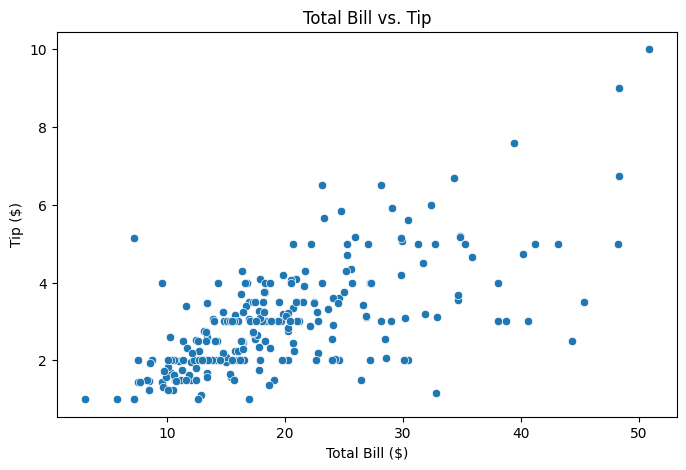

In [78]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.title("Total Bill vs. Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

The scatter plot shows that there seems to be a linear relationship between tip and total bill. Showing that as the total bill increases the tip also increases.

#### Numerical vs Categorical

Here we often check for patterns in by aggragating data across the different categories and inspecting the distribution of individual categories in the dataset.

In [68]:
tips["sex"].unique()

array(['Female', 'Male'], dtype=object)

In [69]:
tips.loc[tips["sex"]=="Male"]["tip"].mean()

np.float64(3.0896178343949043)

In [70]:
tips.loc[tips["sex"]=="Female"]["tip"].mean()

np.float64(2.8334482758620685)

In [71]:
tips.groupby("sex")["tip"].mean()

sex
Female    2.833448
Male      3.089618
Name: tip, dtype: float64

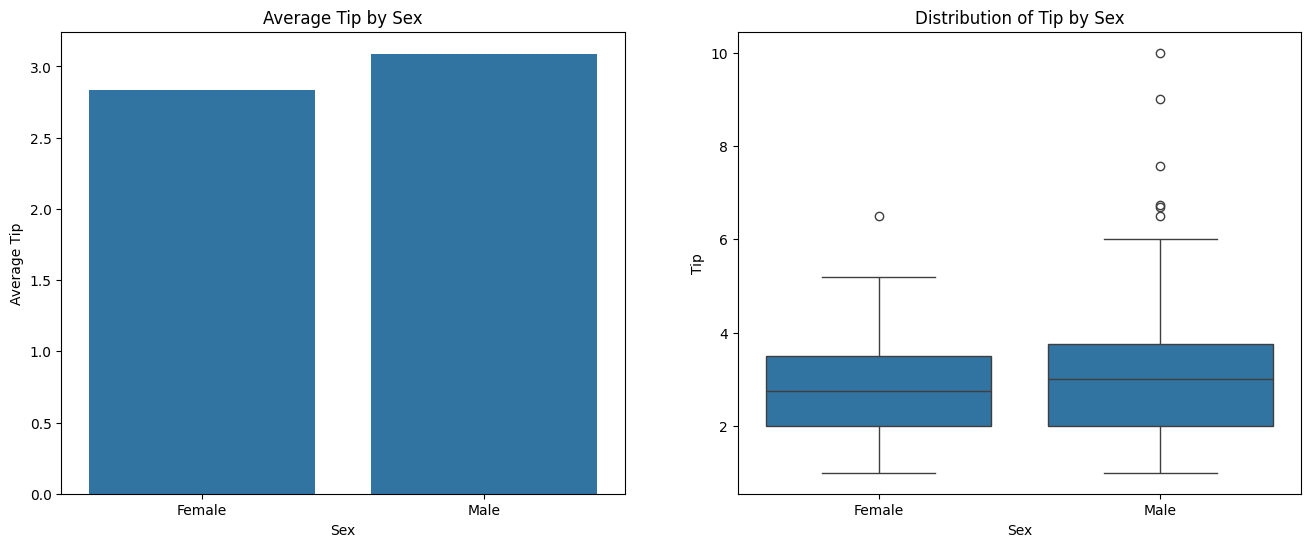

In [72]:
_, ax = plt.subplots(1, 2, figsize=(16, 6))
avg_tip_by_gender = tips.groupby("sex")["tip"].mean()

sns.barplot(avg_tip_by_gender, ax=ax[0])
ax[0].set_title("Average Tip by Sex")
ax[0].set_xlabel("Sex")
ax[0].set_ylabel("Average Tip")

sns.boxplot(tips, x="sex", y="tip", ax=ax[1])
ax[1].set_title("Distribution of Tip by Sex")
ax[1].set_xlabel("Sex")
ax[1].set_ylabel("Tip");

The plot above shows that on average men pay slightly higher tip than women. Although there are outliers in both categories, the outliers seem to be more common in the male category.

#### Categorical vs Categorical

A helpful tool for analysing relationship between categorical variables is a contingency table, a table of
counts by category.

In [73]:
pd.crosstab(tips["sex"], tips["smoker"], margins=True)

smoker,No,Yes,All
sex,,,
Female,54,33,87
Male,97,60,157
All,151,93,244


In [74]:
pd.crosstab(tips["sex"], tips["smoker"], margins=True, normalize="index")

smoker,No,Yes
sex,,
Female,0.620690,0.379310
Male,0.617834,0.382166
All,0.618852,0.381148


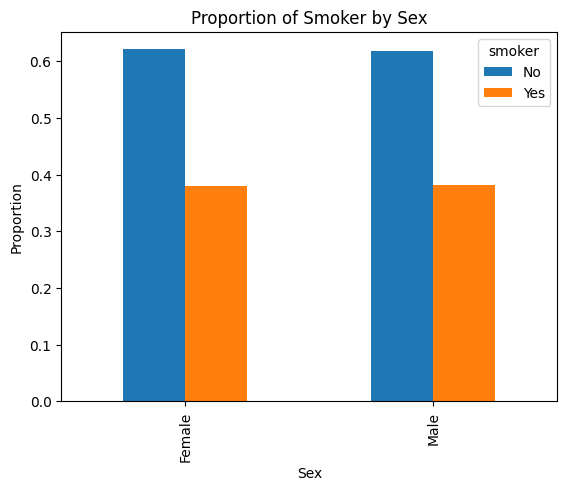

In [75]:
sex_smoker = pd.crosstab(tips["sex"], tips["smoker"], normalize="index")
sex_smoker.plot(kind="bar")
plt.title("Proportion of Smoker by Sex")
plt.xlabel("Sex")
plt.ylabel("Proportion");

### Mutual Information Score

The mutual information score is a measure that quantifies the amount of information one random variable contains about another. It expresses how much knowing the value of one variable reduces the uncertainty or unpredictability about the other variable. If two variables are completely independent, their mutual information score is zero, indicating no shared information. Conversely, if one variable perfectly predicts the other, the mutual information score is high, reflecting a strong dependency between them.

In [76]:
from sklearn.metrics import mutual_info_score

In [77]:
mutual_info_score(tips["smoker"], tips["day"])

0.05320571440777559

#### Exercise 3

Use the tips dataset to answer the following questions:

1. Create a scatterplot showing the relationship between tip and size.
2. Create a barplot and a box plot to inspect relationship between tip and smoker. Write a comment on your observation in two or three sentences.
3. Create a barplot and a box plot to inspect relationship between tip and time. Write a comment on your observation in two or three sentences.
4. Create a contingency table of `smoker` and `day` column. Normalize the table by based on the rows. What do you notice?
5. What is the mutual information score of `smoker` and `day` column?

### Answers
## Q1